# Analysis

Nina Haide

## Data Set

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import pandas as pd

In [4]:
df = pd.read_csv("https://raw.githubusercontent.com/foorilla/ai-jobs-net-salaries/main/salaries.csv")

# Filter to DACH countries
dach = df[df["company_location"].isin(["DE", "AT", "CH"])].copy()

print(dach.shape)
print(dach["company_location"].value_counts())

dach.to_csv("salaries_dach.csv", index=False)

(873, 11)
company_location
DE    455
AT    355
CH     63
Name: count, dtype: int64


In [5]:
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2025,EX,FT,Head of Data,348516,USD,348516,US,0,US,M
1,2025,EX,FT,Head of Data,232344,USD,232344,US,0,US,M
2,2025,SE,FT,Data Scientist,145400,USD,145400,US,0,US,M
3,2025,SE,FT,Data Scientist,81600,USD,81600,US,0,US,M
4,2025,MI,FT,Engineer,160000,USD,160000,US,100,US,M


## Descriptive Statistics

This section explores the structure and distribution of the DACH AI/ML salary dataset through summary statistics, categorical value counts and numeric distributions.

### Summary Statistics

In [7]:
print("Shape:", dach.shape)
print("\n--- Numeric Summary ---")
dach.describe()

Shape: (873, 11)

--- Numeric Summary ---


,work_year,salary,salary_in_usd,remote_ratio
count,873.000000,8.730000e+02,873.000000,873.000000
mean,2024.366552,8.844284e+04,86267.671249,13.745704
std,0.977208,1.597968e+05,62939.940663,32.658427
min,2020.000000,1.400000e+04,15966.000000,0.000000
25%,2024.000000,4.611600e+04,49263.000000,0.000000
50%,2025.000000,6.500000e+04,69300.000000,0.000000
75%,2025.000000,9.500000e+04,97727.000000,0.000000
max,2025.000000,4.000000e+06,793136.000000,100.000000


The `describe()` output shows salary ranges, experience distribution via `remote_ratio` and the spread of `work_year`. The wide range in `salary_in_usd` suggests significant variation across roles and seniority levels in the DACH region.

### Categorical Counts

In [8]:
categorical_cols = ["experience_level", "employment_type", "company_size", "company_location"]

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(dach[col].value_counts())


--- experience_level ---
experience_level
SE    344
MI    323
EN    196
EX     10
Name: count, dtype: int64

--- employment_type ---
employment_type
FT    849
PT     20
CT      4
Name: count, dtype: int64

--- company_size ---
company_size
M    793
L     54
S     26
Name: count, dtype: int64

--- company_location ---
company_location
DE    455
AT    355
CH     63
Name: count, dtype: int64


Most entries are full-time (`FT`) positions at medium-sized companies (`M`). Germany (`DE`) dominates the dataset, with Austria (`AT`) and Switzerland (`CH`) underrepresented, reflecting both market size and salary reporting culture differences across the DACH region.

### Distributions

In [20]:
import requests
from datetime import date

# Fetch today's exchange rates
response = requests.get("https://api.frankfurter.app/latest?base=EUR")
rates = response.json()["rates"]

today = date.today()
print(f"Exchange rates as of {today} (base: EUR)")
print(f"  USD → EUR: {1 / rates['USD']:.4f}")
print(f"  CHF → EUR: {1 / rates['CHF']:.4f}")

# Convert all salaries to EUR
def to_eur(row):
    currency = row["salary_currency"]
    amount = row["salary"]
    if currency == "EUR":
        return amount
    elif currency in rates:
        return round(amount / rates[currency], 2)
    else:
        return None

dach["salary_eur"] = dach.apply(to_eur, axis=1)
print(f"\nRows with salary_eur: {dach['salary_eur'].notna().sum()} / {len(dach)}")

Exchange rates as of 2026-05-06 (base: EUR)
  USD → EUR: 0.8557
  CHF → EUR: 1.0911

Rows with salary_eur: 873 / 873


In [21]:
# Remove outliers
dach_clean = dach[(dach["salary_eur"] >= 15000) & (dach["salary_eur"] <= 400000)].copy()
print(f"Removed {len(dach) - len(dach_clean)} outlier rows")
print(f"Max salary_eur in dach_clean: {dach_clean['salary_eur'].max()}")
print(dach_clean["company_location"].value_counts())

Removed 3 outlier rows
Max salary_eur in dach_clean: 310420.08
company_location
DE    454
AT    353
CH     63
Name: count, dtype: int64


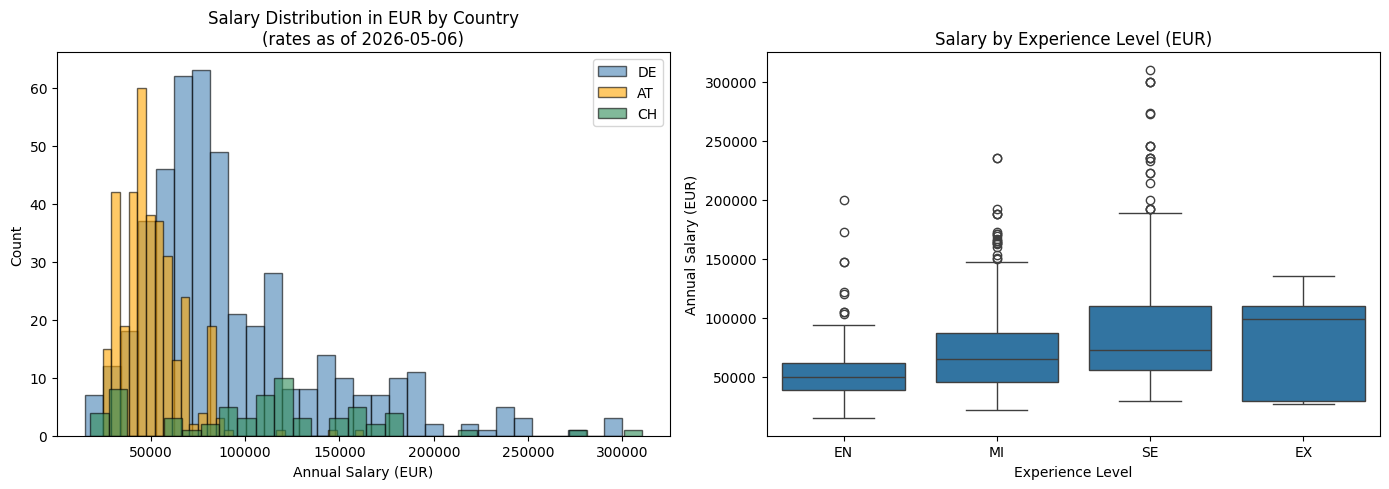

In [23]:
# Plot distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Salary distribution by country
for country, color in zip(["DE", "AT", "CH"], ["steelblue", "orange", "seagreen"]):
    subset = dach_clean[dach_clean["company_location"] == country]["salary_eur"].dropna()
    axes[0].hist(subset, bins=30, alpha=0.6, label=country, color=color, edgecolor="black")
axes[0].set_title(f"Salary Distribution in EUR by Country\n(rates as of {today})")
axes[0].set_xlabel("Annual Salary (EUR)")
axes[0].set_ylabel("Count")
axes[0].legend()

# Salary by experience level
exp_order = ["EN", "MI", "SE", "EX"]
sns.boxplot(data=dach_clean, x="experience_level", y="salary_eur",
            order=exp_order, ax=axes[1])
axes[1].set_title("Salary by Experience Level (EUR)")
axes[1].set_xlabel("Experience Level")
axes[1].set_ylabel("Annual Salary (EUR)")

plt.tight_layout()
plt.savefig("viz_descriptive_stats.png", dpi=150)
plt.show()

All salaries have been converted to EUR using live exchange rates fetched from the Frankfurter API (European Central Bank data), allowing direct comparison across Germany, Austria and Switzerland on a common scale. Two outlier entries were removed: one salary below €15,000 (likely part-time or internship) and one Austrian entry of €753,480 which is implausible as an annual figure and would distort the visualizations.

**Salary distribution by country:** Germany and Austria both cluster heavily in the €40,000–€100,000 range, with Germany showing a longer right tail reflecting more senior and internationally-paid roles. Austria's distribution is narrower and peaks slightly lower, consistent with a smaller and less internationally exposed AI job market. Switzerland has fewer entries but a notably wider spread, with several salaries above €150,000 — reflecting its higher cost of living and concentration of senior roles.

**Salary by experience level:** There is a clear upward progression from Junior (EN) to Senior (SE), which is expected. The Executive (EX) median is surprisingly close to Senior, likely due to the small number of EX entries in the DACH region rather than a genuine flattening of compensation at the top. The wide interquartile range at Senior level reflects the diversity of roles and industries captured under that label.

In [3]:
pip freeze > requirements.txt

Note: you may need to restart the kernel to use updated packages.
